In [2]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Derivation of Column Density Maps Routine
from Derive_Density_Maps import derive_density_maps, convert_to_mass

# Visualization Tools
from visualization_tools import show_regions_with_sections, show_Minkowski_Functionals, show_sections_OrionB_vertical, visualize_Mass_Size_D_Diagrams, visualize_Mass_Size_D_Diagramm_as_One

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals, horizontal_marching_minkowski_functionals, vertical_marching_minkowski_functionals, intercept_corrected_minkowski_functionals 

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# Dendogram-like Tracker
from region_tracker import track_largest_regions, save_regions_to_pickle, load_regions_from_pickle, get_region_from_fractal_dimension_mass_and_size

# Derive Density Maps
N_H2, N_H2_OA, N_H2_OB, wcs = derive_density_maps()

[15:30:51] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=371467;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=105143;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_2576\95276728.py:29: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Column Density Threshold [$\mathrm{cm}^{-2}$]', fontsize=13)


2.9388857827004227
2.859715631165698


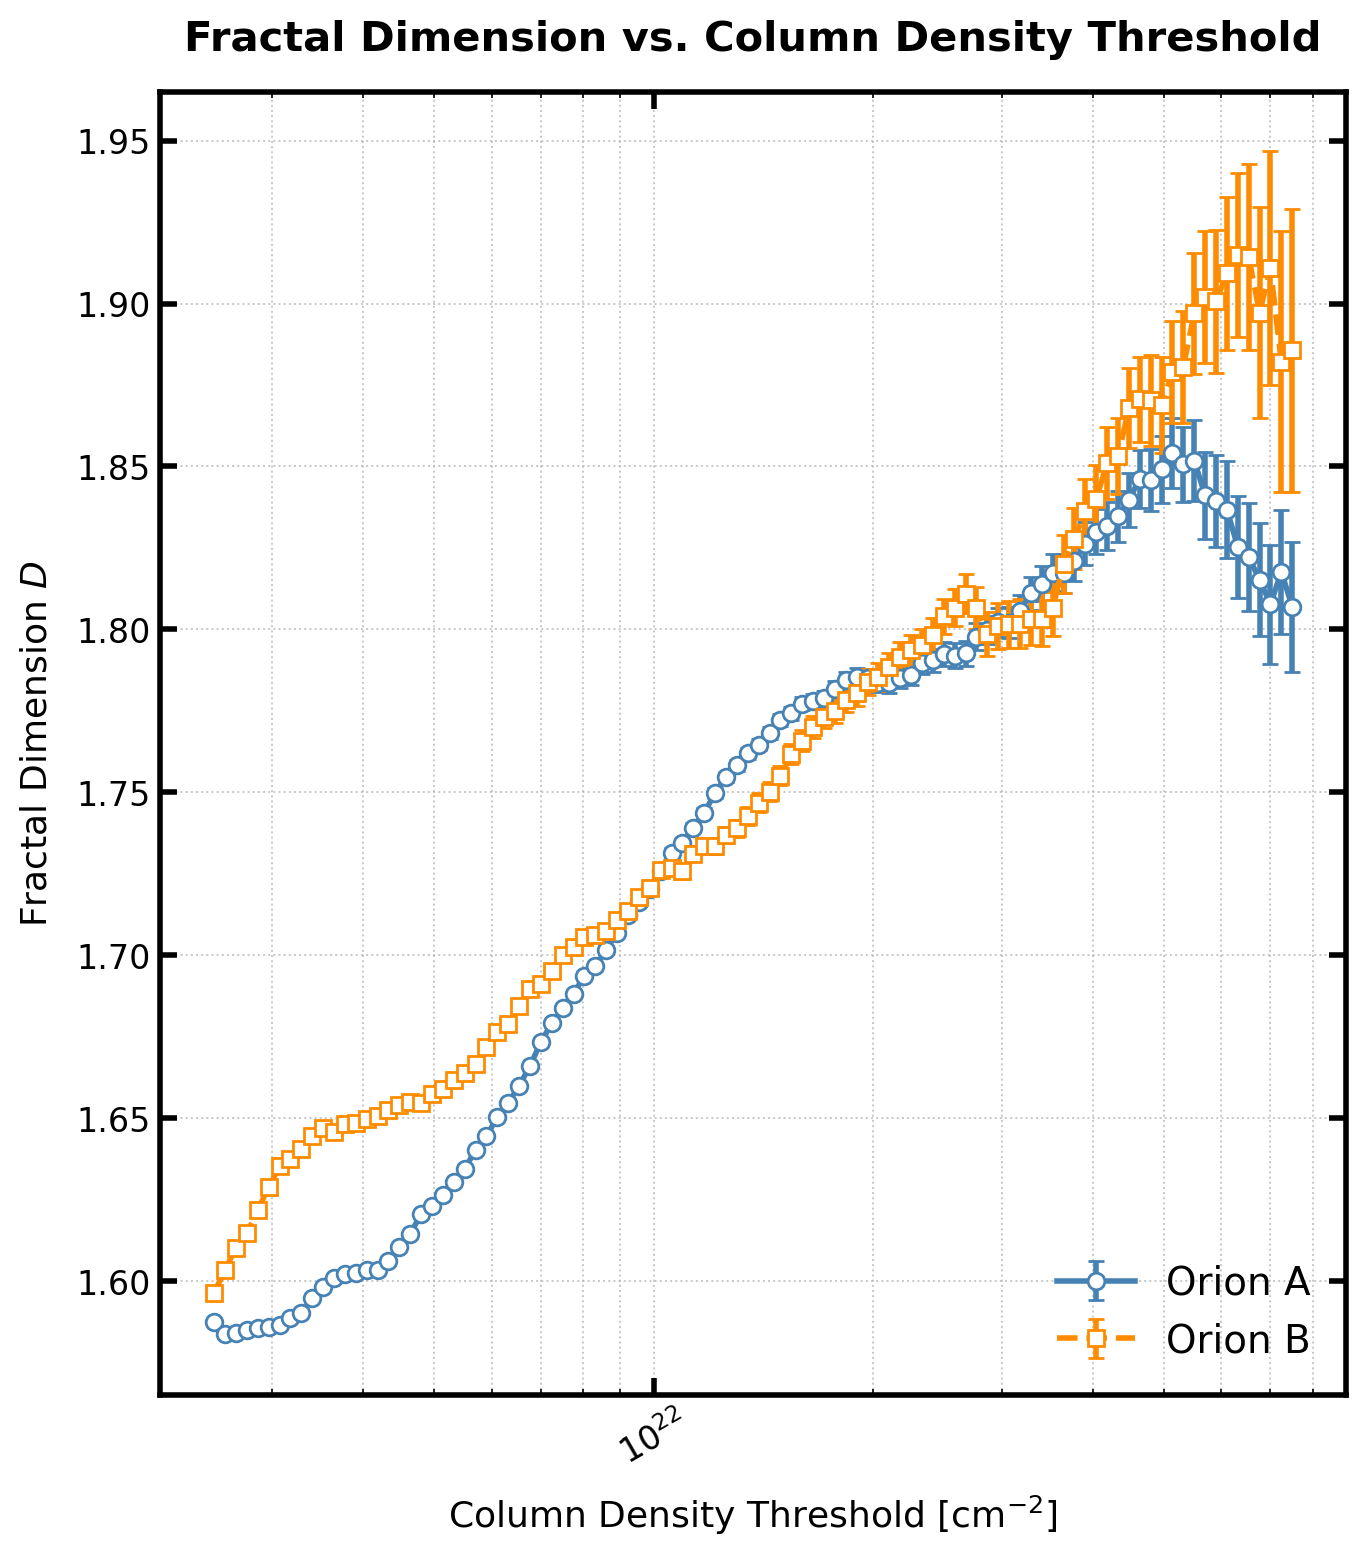

In [3]:
# Fractal Dimension as a function of N

# Orion A
region_name = "Orion A"

# overall, these work best for the whole region
threshold_min = 2.5e21
threshold_max = 7.5e22 # This works well when the fractal dimension is calculated for the whole region, but for the individual regions it might be good to go further down
# threshold_max = 1.0e23

# Minkowski
results_OA = standard_minkowski_functionals(N_H2_OA, threshold_min = threshold_min, threshold_max = threshold_max)

results_OB = standard_minkowski_functionals(N_H2_OB, threshold_min = threshold_min, threshold_max = threshold_max)

plt.figure(figsize=(7, 8))

# Plot with error bars
plt.errorbar(results_OA["thresholds"], results_OA["fractal_dimension"], 
             yerr=results_OA["sigma_D"], fmt='o-', 
             label="Orion A", color='steelblue', markersize=6, capsize=3)

plt.errorbar(results_OB["thresholds"], results_OB["fractal_dimension"], 
             yerr=results_OB["sigma_D"], fmt='s--', 
             label="Orion B", color='darkorange', markersize=6, capsize=3)

# Title and labels
plt.title("Fractal Dimension vs. Column Density Threshold", fontweight='bold', fontsize=15, pad=15)
plt.xlabel('Column Density Threshold [$\mathrm{cm}^{-2}$]', fontsize=13)
plt.ylabel('Fractal Dimension $D$', fontsize=13)

# Log scale and grid
plt.xscale("log")
plt.grid(True, which='both', linestyle=':', linewidth=0.7, alpha=0.7)

# Tick adjustments
plt.tick_params(axis='both', which='major', labelsize=12)
plt.xticks(rotation=30)

# Legend
plt.legend(frameon=False, fontsize=14, loc='lower right')

# Tight layout for slides
plt.tight_layout()